In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

deliveries_df = pd.read_csv('/content/deliveries.csv')

print("Columns in deliveries_df:", deliveries_df.columns.tolist())


deliveries_df['extra_runs'] = deliveries_df['extra_runs'].fillna(0)


deliveries_df['extras_type'] = deliveries_df['extras_type'].fillna('none')


deliveries_df_filtered = deliveries_df[deliveries_df['inning'].isin([1, 2])].copy()


deliveries_df_filtered['total_extras'] = deliveries_df_filtered['extra_runs']


extras_summary = deliveries_df_filtered.groupby(['bowling_team', 'inning']).agg(
    total_extras=('total_extras', 'sum'),
    average_extras=('total_extras', 'mean')
).reset_index()

print("Total and average extras conceded by each bowling team per inning:")
display(extras_summary)

Columns in deliveries_df: ['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']
Total and average extras conceded by each bowling team per inning:


,bowling_team,inning,total_extras,average_extras
0,Chennai Super Kings,1,834,0.062509
1,Chennai Super Kings,2,1008,0.066185
2,Deccan Chargers,1,294,0.073795
3,Deccan Chargers,2,365,0.072206
4,Delhi Capitals,1,421,0.067446
5,Delhi Capitals,2,303,0.061101
6,Delhi Daredevils,1,718,0.065721
7,Delhi Daredevils,2,550,0.070567
8,Gujarat Lions,1,90,0.045685
9,Gujarat Lions,2,98,0.062420


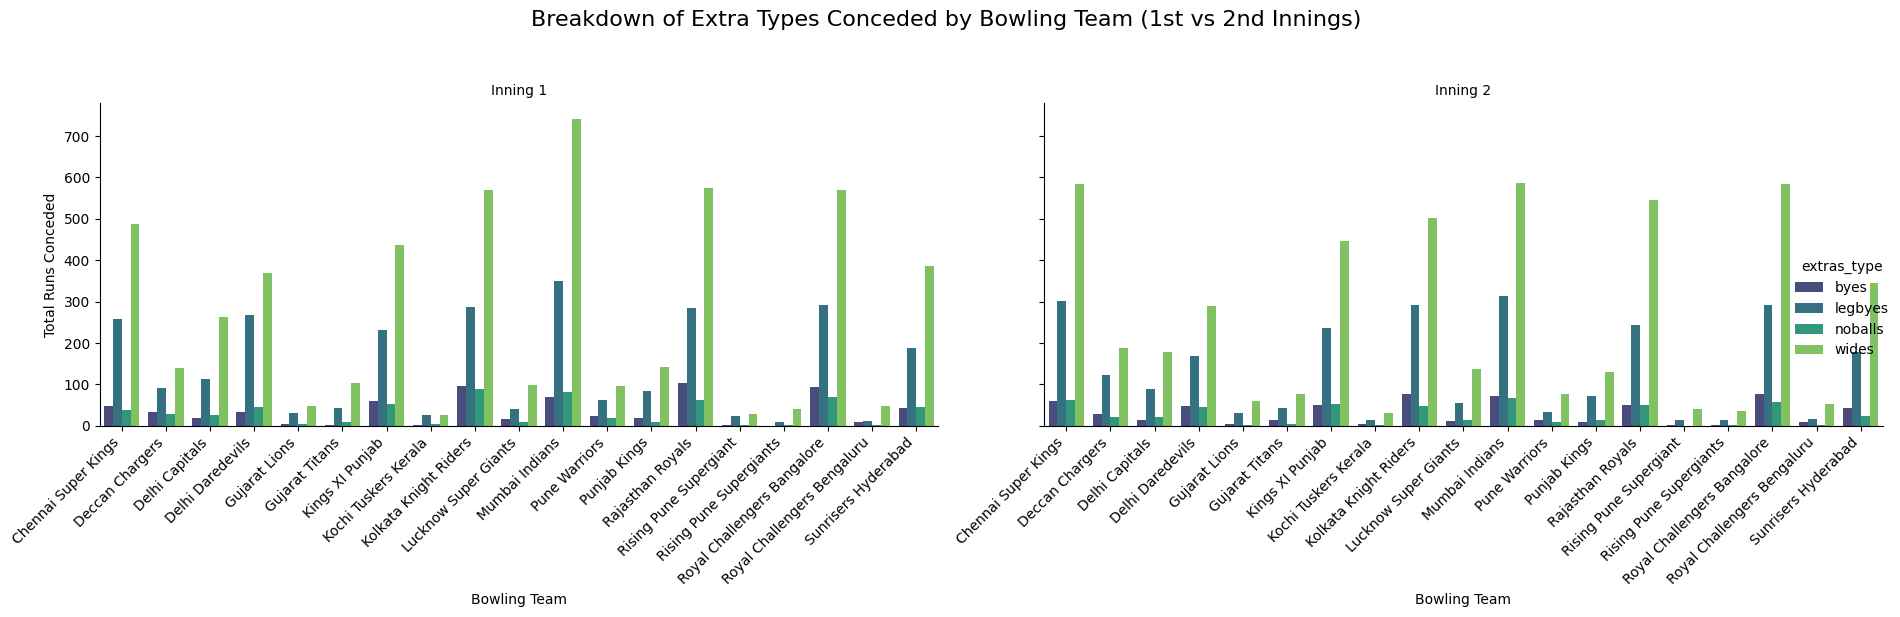

In [ ]:
extras_filter = deliveries_df_filtered[deliveries_df_filtered['extra_runs'] > 0].copy()

filter_data_grouped = extras_filter.groupby(['bowling_team', 'inning', 'extras_type'])['extra_runs'].sum().reset_index()

filter_data_grouped = filter_data_grouped.rename(columns={'extra_runs': 'total_runs'})

filter_data_melted_filtered = filter_data_grouped[filter_data_grouped['extras_type'].isin(['wides', 'noballs', 'legbyes', 'byes'])]


g = sns.catplot(data=filter_data_melted_filtered, x='bowling_team',y='total_runs',hue='extras_type',col='inning',kind='bar',palette='viridis',errorbar=None,height=6, aspect=1.5
)

g.set_axis_labels('Bowling Team', 'Total Runs Conceded')
g.set_titles('Inning {col_name}')
g.set_xticklabels(rotation=45, ha='right')
plt.suptitle('Breakdown of Extra Types Conceded by Bowling Team (1st vs 2nd Innings)', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()